# 04 - Social Network Analysis

**Purpose:** Let's build the social-exposure layer used in community-attention forecasting.

The Yelp friendship graph is static, so we will treat network measures as context and exposure, not causal influence. To avoid future leakage, all reviewer activity used to define active reviewers, edge weights, and community labels is limited to the same training period used later by the forecasting models: **2015-02 through 2017-12**.


## Objectives

- Use only the forecasting training-window reviews: **2015-02 through 2017-12**.
- Test active-reviewer thresholds: **2, 3, 5, 10, 20** training-window reviews.
- Keep nodes as active New Orleans reviewers from that training window.
- Keep edges as friendship links between active training-window reviewers.
- Weight edges by training-window behavioral overlap: shared New Orleans businesses and reviewed-category similarity.
- Export degree, weighted degree, PageRank, weighted PageRank, component, and community features.


## Graph Design

let's construct the reviewer friendship graph for active reviewers using only the review activity available inside the forecasting training window.


In [1]:
# Imports
from pathlib import Path
import json
from collections import Counter, defaultdict
from math import log1p

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "sna"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Input files
BUSINESSES_PATH = INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USERS_PATH = INTERIM_DIR / "users.jsonl"

# Output files
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"
GRAPH_SUMMARY_PATH = PROCESSED_DIR / "social_graph_summary.json"
THRESHOLD_SENSITIVITY_PATH = PROCESSED_DIR / "active_reviewer_threshold_sensitivity.csv"

# Train window
SNA_TRAIN_START = pd.Period("2015-02", freq="M")
SNA_TRAIN_END = pd.Period("2017-12", freq="M")

# Thresholds and weights
THRESHOLD_CANDIDATES = [2, 3, 5, 10, 20]

EDGE_BASE_WEIGHT = 1.0
SHARED_BUSINESS_WEIGHT = 1.0
CATEGORY_OVERLAP_WEIGHT = 1.0

# Plot style
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root: {PROJECT_ROOT.name}")

Project root: community-forecasting-yelp


In [2]:
# Load New Orleans review and user extracts 
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

In [3]:
# Business categories
business_categories = {}
for record in iter_jsonl(BUSINESSES_PATH):
    categories = record.get("categories") or ""
    business_categories[record["business_id"]] = {
        category.strip().casefold()
        for category in categories.split(",")
        if category.strip()
    }

# Review activity
user_review_counts = Counter()
user_business_sets = defaultdict(set)
user_category_sets = defaultdict(set)
sna_review_month_counts = Counter()
total_local_reviews = 0
training_window_reviews = 0

for record in iter_jsonl(REVIEWS_PATH):
    total_local_reviews += 1
    review_month = pd.Period(record["date"][:7], freq="M")
    if review_month < SNA_TRAIN_START or review_month > SNA_TRAIN_END:
        continue

    training_window_reviews += 1
    sna_review_month_counts[str(review_month)] += 1
    uid = record["user_id"]
    business_id = record["business_id"]
    user_review_counts[uid] += 1
    user_business_sets[uid].add(business_id)
    user_category_sets[uid].update(business_categories.get(business_id, set()))

# SNA users
all_reviewing_user_ids = set(user_review_counts)

print(f"SNA review window: {SNA_TRAIN_START} to {SNA_TRAIN_END}")
print(f"Training-window reviews used for SNA: {training_window_reviews:,} of {total_local_reviews:,} local reviews")
print(f"Reviewing users in SNA window: {len(all_reviewing_user_ids):,}")
print(f"Threshold candidates: {THRESHOLD_CANDIDATES}")

SNA review window: 2015-02 to 2017-12
Training-window reviews used for SNA: 206,862 of 635,521 local reviews
Reviewing users in SNA window: 92,329
Threshold candidates: [2, 3, 5, 10, 20]


## Weighted Network

Here, edges represent friendship links among reviewers who were active in the training window. Edge weights summarize shared business/category context from that same window.


In [4]:
# Edge similarity
def jaccard_similarity(left, right):
    if not left or not right:
        return 0.0
    return len(left & right) / len(left | right)


# Edge attributes
def local_friendship_edge(uid, fid):
    shared_business_count = len(user_business_sets[uid] & user_business_sets[fid])
    category_jaccard = jaccard_similarity(user_category_sets[uid], user_category_sets[fid])
    weight = (
        EDGE_BASE_WEIGHT
        + SHARED_BUSINESS_WEIGHT * log1p(shared_business_count)
        + CATEGORY_OVERLAP_WEIGHT * category_jaccard
    )
    return {
        "weight": weight,
        "shared_business_count": shared_business_count,
        "category_jaccard": category_jaccard,
    }


# Active users by threshold
threshold_active_ids = {
    threshold: {uid for uid, count in user_review_counts.items() if count >= threshold}
    for threshold in THRESHOLD_CANDIDATES
}

threshold_graphs = {}
active_profile_counts = {}

for threshold, active_ids in threshold_active_ids.items():
    graph = nx.Graph()
    graph.add_nodes_from(active_ids)
    threshold_graphs[threshold] = graph
    active_profile_counts[threshold] = 0


# Build threshold graphs
matched_profiles = 0

for record in iter_jsonl(USERS_PATH):
    uid = record["user_id"]
    uid_review_count = user_review_counts.get(uid)
    if uid_review_count is None:
        continue

    matched_profiles += 1
    qualifying_thresholds = [threshold for threshold in THRESHOLD_CANDIDATES if uid_review_count >= threshold]

    if not qualifying_thresholds:
        continue

    for threshold in qualifying_thresholds:
        active_profile_counts[threshold] += 1

    friends = record.get("friends") or ""
    if friends == "None":
        continue

    for fid in friends.replace(", ", ",").split(","):
        fid = fid.strip()
        if not fid or uid >= fid:
            continue

        friend_review_count = user_review_counts.get(fid)
        if friend_review_count is None:
            continue

        max_shared_threshold = min(uid_review_count, friend_review_count)
        edge_attributes = local_friendship_edge(uid, fid)

        for threshold in THRESHOLD_CANDIDATES:
            if threshold <= max_shared_threshold:
                threshold_graphs[threshold].add_edge(uid, fid, **edge_attributes)


# Summarize graph
def graph_threshold_summary(threshold, graph):
    degree_values = [degree for _, degree in graph.degree()]
    weighted_degree_values = [degree for _, degree in graph.degree(weight="weight")]
    edge_weights = [data["weight"] for _, _, data in graph.edges(data=True)]
    shared_business_counts = [data["shared_business_count"] for _, _, data in graph.edges(data=True)]
    category_jaccards = [data["category_jaccard"] for _, _, data in graph.edges(data=True)]
    components = sorted(nx.connected_components(graph), key=len, reverse=True)
    largest_component_size = len(components[0]) if components else 0
    isolated_active_users = sum(1 for value in degree_values if value == 0)

    return {
        "active_review_threshold": threshold,
        "reviewing_users": len(all_reviewing_user_ids),
        "matched_user_profiles": matched_profiles,
        "active_users": len(threshold_active_ids[threshold]),
        "active_user_share": len(threshold_active_ids[threshold]) / len(all_reviewing_user_ids),
        "graph_nodes": graph.number_of_nodes(),
        "graph_edges": graph.number_of_edges(),
        "mean_edge_weight": pd.Series(edge_weights).mean() if edge_weights else 0,
        "mean_edge_shared_business_count": pd.Series(shared_business_counts).mean() if shared_business_counts else 0,
        "mean_edge_category_jaccard": pd.Series(category_jaccards).mean() if category_jaccards else 0,
        "connected_components": len(components),
        "largest_component_size": largest_component_size,
        "largest_component_share": largest_component_size / graph.number_of_nodes() if graph.number_of_nodes() else 0,
        "isolated_active_users": isolated_active_users,
        "isolated_active_user_share": isolated_active_users / graph.number_of_nodes() if graph.number_of_nodes() else 0,
        "median_friend_degree": pd.Series(degree_values).median() if degree_values else 0,
        "p90_friend_degree": pd.Series(degree_values).quantile(0.9) if degree_values else 0,
        "median_friend_weighted_degree": pd.Series(weighted_degree_values).median() if weighted_degree_values else 0,
        "p90_friend_weighted_degree": pd.Series(weighted_degree_values).quantile(0.9) if weighted_degree_values else 0,
    }


# Save threshold sensitivity
threshold_sensitivity = pd.DataFrame([
    graph_threshold_summary(threshold, threshold_graphs[threshold])
    for threshold in THRESHOLD_CANDIDATES
])

threshold_sensitivity.to_csv(THRESHOLD_SENSITIVITY_PATH, index=False)
threshold_sensitivity

,active_review_threshold,reviewing_users,matched_user_profiles,active_users,active_user_share,graph_nodes,graph_edges,mean_edge_weight,mean_edge_shared_business_count,mean_edge_category_jaccard,connected_components,largest_component_size,largest_component_share,isolated_active_users,isolated_active_user_share,median_friend_degree,p90_friend_degree,median_friend_weighted_degree,p90_friend_weighted_degree
0,2,92329,92329,34143,0.369797,34143,64381,1.422596,0.482083,0.205997,21321,12384,0.362710,20935,0.613156,0.0,7.0,0.000000,9.469196
1,3,92329,92329,18968,0.205439,18968,40840,1.552909,0.722821,0.236312,11087,7728,0.407423,10941,0.576814,0.0,9.0,0.000000,11.760870
2,5,92329,92329,8351,0.090448,8351,23563,1.740572,1.147265,0.260428,4254,4054,0.485451,4213,0.504490,0.0,12.0,0.000000,18.555580
3,10,92329,92329,2218,0.024023,2218,10606,2.100277,2.138789,0.283482,836,1370,0.617674,823,0.371055,1.0,25.0,2.599140,49.405552
4,20,92329,92329,579,0.006271,579,5284,2.501567,3.454580,0.317261,101,479,0.827288,100,0.172712,7.0,48.2,15.814599,116.146168


## Graph Choice

let's use a threshold of **5 training-window reviews**. It preserves a meaningful active-reviewer population while keeping the largest component large enough for centrality and community features.


In [5]:
ACTIVE_REVIEW_THRESHOLD = 5

# Active graph
active_user_ids = threshold_active_ids[ACTIVE_REVIEW_THRESHOLD]
G = threshold_graphs[ACTIVE_REVIEW_THRESHOLD].copy()
active_profiles = active_profile_counts[ACTIVE_REVIEW_THRESHOLD]

print(f"Selected active-reviewer threshold: {ACTIVE_REVIEW_THRESHOLD}")
print(f"Matched user profiles: {matched_profiles:,}")
print(f"Active user profiles: {active_profiles:,}")
print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")

Selected active-reviewer threshold: 5
Matched user profiles: 92,329
Active user profiles: 8,351
Graph nodes: 8,351
Graph edges: 23,563


## Network Features

let's calculate centrality and community features from the graph, then aggregate those fixed social-exposure features over reviewers for each later business-month.


In [6]:
# Graph centrality
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))

# Components
components = sorted(nx.connected_components(G), key=len, reverse=True)
component_id_by_user = {}
component_size_by_user = {}

for cid, nodes in enumerate(components):
    for node in nodes:
        component_id_by_user[node] = cid
        component_size_by_user[node] = len(nodes)

# PageRank
pagerank = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6, weight=None) if G.number_of_edges() else {
    node: 0.0 for node in G.nodes
}
weighted_pagerank = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6, weight="weight") if G.number_of_edges() else {
    node: 0.0 for node in G.nodes
}

# Edge-level sums
edge_shared_business_sum = Counter()
edge_category_jaccard_sum = Counter()

for left, right, data in G.edges(data=True):
    edge_shared_business_sum[left] += data["shared_business_count"]
    edge_shared_business_sum[right] += data["shared_business_count"]
    edge_category_jaccard_sum[left] += data["category_jaccard"]
    edge_category_jaccard_sum[right] += data["category_jaccard"]

# Friend overlap features
avg_friend_shared_businesses = {
    uid: edge_shared_business_sum[uid] / degree[uid] if degree.get(uid, 0) else 0.0
    for uid in G.nodes
}
avg_friend_category_overlap = {
    uid: edge_category_jaccard_sum[uid] / degree[uid] if degree.get(uid, 0) else 0.0
    for uid in G.nodes
}

# Communities
community_by_user = {node: -1 for node in G.nodes}
community_method = "not_computed"

if components and len(components[0]) >= 3:
    largest = G.subgraph(components[0]).copy()
    try:
        communities = nx.algorithms.community.louvain_communities(largest, seed=42, weight="weight")
        community_method = "weighted_louvain_largest_component"
        for community_id, nodes in enumerate(communities):
            for node in nodes:
                community_by_user[node] = community_id
    except Exception as exc:
        community_method = f"not_computed: {type(exc).__name__}: {exc}"

# Summary
print(f"Connected components: {len(components):,}")
print(f"Largest component size: {len(components[0]) if components else 0:,}")
print(f"Isolated active users: {sum(1 for _, d in G.degree() if d == 0):,}")
print(f"Mean edge weight: {threshold_sensitivity.loc[threshold_sensitivity['active_review_threshold'] == ACTIVE_REVIEW_THRESHOLD, 'mean_edge_weight'].iloc[0]:.3f}")
print(f"Community method: {community_method}")

Connected components: 4,254
Largest component size: 4,054
Isolated active users: 4,213
Mean edge weight: 1.741
Community method: weighted_louvain_largest_component


In [7]:
# Build feature table
rows = []

for uid in all_reviewing_user_ids:
    rows.append({
        "user_id": uid,
        "subset_review_count": user_review_counts[uid],
        "active_reviewer": int(uid in active_user_ids),
        "friend_degree": degree.get(uid, 0),
        "friend_weighted_degree": weighted_degree.get(uid, 0.0),
        "pagerank": pagerank.get(uid, 0.0),
        "weighted_pagerank": weighted_pagerank.get(uid, 0.0),
        "avg_friend_shared_businesses": avg_friend_shared_businesses.get(uid, 0.0),
        "avg_friend_category_overlap": avg_friend_category_overlap.get(uid, 0.0),
        "component_id": component_id_by_user.get(uid, -1),
        "component_size": component_size_by_user.get(uid, 0),
        "community_id": community_by_user.get(uid, -1),
    })

user_network_features = pd.DataFrame(rows)
user_network_features.to_csv(USER_NETWORK_FEATURES_PATH, index=False)

# Selected threshold summary
selected_threshold_summary = threshold_sensitivity[
    threshold_sensitivity["active_review_threshold"] == ACTIVE_REVIEW_THRESHOLD
].iloc[0].to_dict()

# Graph summary
summary = {
    "active_review_threshold": ACTIVE_REVIEW_THRESHOLD,
    "edge_weight_formula": "1 + log1p(shared_business_count) + category_jaccard",
    "sna_review_window_start": str(SNA_TRAIN_START),
    "sna_review_window_end": str(SNA_TRAIN_END),
    "sna_window_basis": "matches 06_forecasting_models target_month_str training split",
    "training_window_reviews": int(training_window_reviews),
    "total_local_reviews_available": int(total_local_reviews),
    "reviewing_users": len(all_reviewing_user_ids),
    "matched_user_profiles": matched_profiles,
    "active_users": len(active_user_ids),
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "mean_edge_weight": selected_threshold_summary["mean_edge_weight"],
    "mean_edge_shared_business_count": selected_threshold_summary["mean_edge_shared_business_count"],
    "mean_edge_category_jaccard": selected_threshold_summary["mean_edge_category_jaccard"],
    "connected_components": len(components),
    "largest_component_size": len(components[0]) if components else 0,
    "isolated_active_users": sum(1 for _, d in G.degree() if d == 0),
    "community_method": community_method,
    "communities_assigned": len(set(v for v in community_by_user.values() if v >= 0)),
    "threshold_sensitivity_output": str(THRESHOLD_SENSITIVITY_PATH.relative_to(PROJECT_ROOT)),
    "output": str(USER_NETWORK_FEATURES_PATH.relative_to(PROJECT_ROOT)),
}

# Save summary
with GRAPH_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")

summary

{'active_review_threshold': 5,
 'edge_weight_formula': '1 + log1p(shared_business_count) + category_jaccard',
 'sna_review_window_start': '2015-02',
 'sna_review_window_end': '2017-12',
 'sna_window_basis': 'matches 06_forecasting_models target_month_str training split',
 'training_window_reviews': 206862,
 'total_local_reviews_available': 635521,
 'reviewing_users': 92329,
 'matched_user_profiles': 92329,
 'active_users': 8351,
 'graph_nodes': 8351,
 'graph_edges': 23563,
 'mean_edge_weight': 1.7405717853432006,
 'mean_edge_shared_business_count': 1.1472647795272248,
 'mean_edge_category_jaccard': 0.2604275800959453,
 'connected_components': 4254,
 'largest_component_size': 4054,
 'isolated_active_users': 4213,
 'community_method': 'weighted_louvain_largest_component',
 'communities_assigned': 30,
 'threshold_sensitivity_output': 'data\\processed\\new_orleans\\active_reviewer_threshold_sensitivity.csv',
 'output': 'data\\processed\\new_orleans\\user_network_features.csv'}

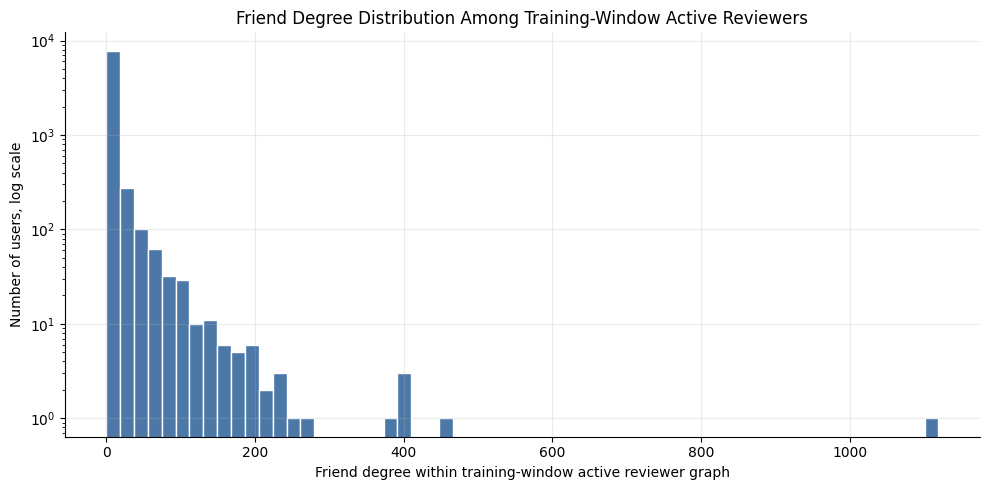

outputs\figures\sna\active_user_degree_distribution.png


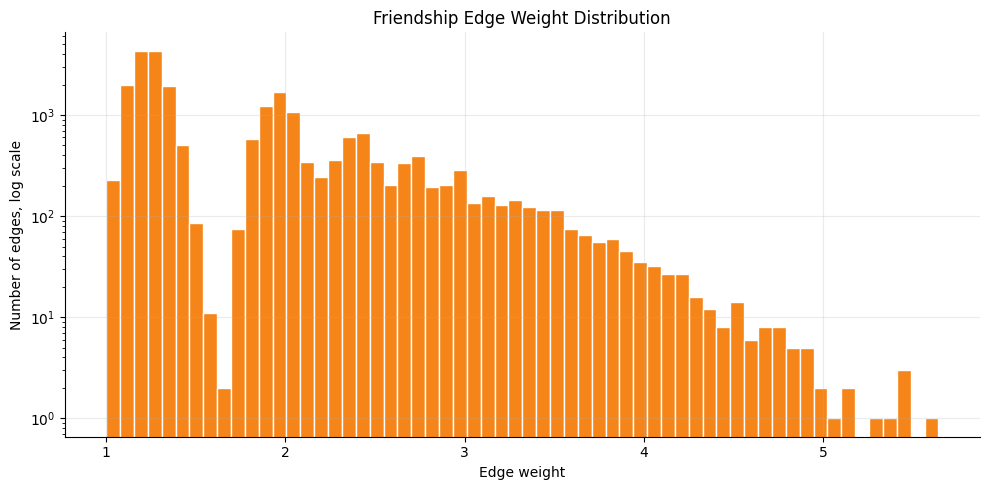

outputs\figures\sna\friendship_edge_weight_distribution.png


{'active_review_threshold': 5,
 'edge_weight_formula': '1 + log1p(shared_business_count) + category_jaccard',
 'sna_review_window_start': '2015-02',
 'sna_review_window_end': '2017-12',
 'sna_window_basis': 'matches 06_forecasting_models target_month_str training split',
 'training_window_reviews': 206862,
 'total_local_reviews_available': 635521,
 'reviewing_users': 92329,
 'matched_user_profiles': 92329,
 'active_users': 8351,
 'graph_nodes': 8351,
 'graph_edges': 23563,
 'mean_edge_weight': 1.7405717853432006,
 'mean_edge_shared_business_count': 1.1472647795272248,
 'mean_edge_category_jaccard': 0.2604275800959453,
 'connected_components': 4254,
 'largest_component_size': 4054,
 'isolated_active_users': 4213,
 'community_method': 'weighted_louvain_largest_component',
 'communities_assigned': 30,
 'threshold_sensitivity_output': 'data\\processed\\new_orleans\\active_reviewer_threshold_sensitivity.csv',
 'output': 'data\\processed\\new_orleans\\user_network_features.csv'}

In [8]:
# Degree distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(list(degree.values()), bins=60, color="#4C78A8", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Friend Degree Distribution Among Training-Window Active Reviewers")
ax.set_xlabel("Friend degree within training-window active reviewer graph")
ax.set_ylabel("Number of users, log scale")
fig.tight_layout()

path = FIGURES_DIR / "active_user_degree_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
print(path.relative_to(PROJECT_ROOT))

# Edge weight distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist([data["weight"] for _, _, data in G.edges(data=True)], bins=60, color="#F58518", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Friendship Edge Weight Distribution")
ax.set_xlabel("Edge weight")
ax.set_ylabel("Number of edges, log scale")
fig.tight_layout()

path = FIGURES_DIR / "friendship_edge_weight_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
print(path.relative_to(PROJECT_ROOT))

summary

Using the 2015-02 to 2017-12 training window, the active reviewer graph is large but fragmented: 8,351 active users form 23,563 friendship edges, yet about half are isolated and there are 4,254 connected components. Edge weights are mostly low-to-moderate, meaning most connected users share limited review overlap or category similarity. Overall, the network has a small connected core with many weakly connected or disconnected reviewers, so social-network features likely capture influence for only part of the user base.

## Degree Distribution

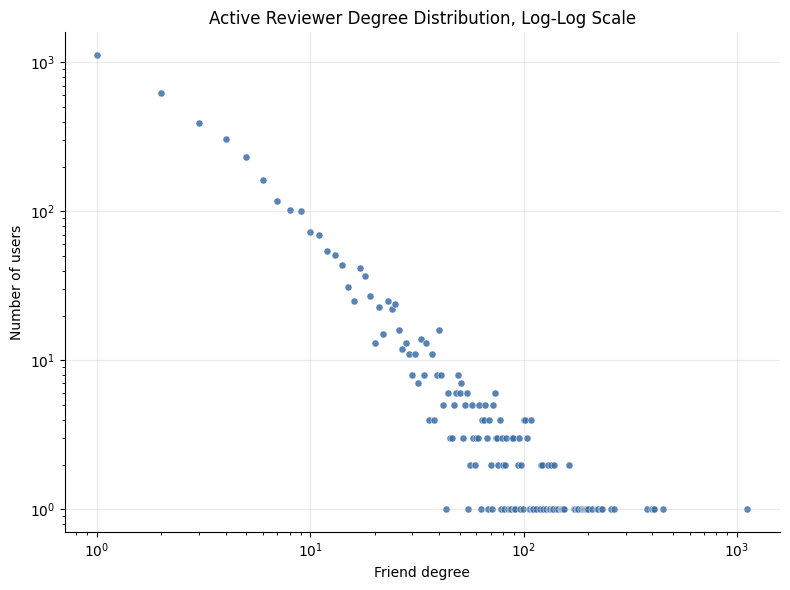

Saved: outputs\figures\sna\degree_distribution_loglog.png
Isolated users: 4,213
Max degree: 1,119
Approximate log-log slope: -1.34; R^2: 0.86


{'nodes': 8351,
 'edges': 23563,
 'isolated_nodes': 4213,
 'max_degree': 1119,
 'median_degree': 0.0,
 'p90_degree': 12.0,
 'approx_loglog_slope': -1.3421798629647903,
 'approx_loglog_r2': 0.8602291356247658,
 'figure': 'outputs\\figures\\sna\\degree_distribution_loglog.png'}

In [9]:
# Imports
import numpy as np

# Add node review counts
review_count_in_sna_window = {
    node: data.get("review_count_in_sna_window", user_review_counts.get(node, 0))
    for node, data in G.nodes(data=True)
}
nx.set_node_attributes(G, review_count_in_sna_window, "review_count_in_sna_window")

# Degree counts
degree_values = pd.Series(dict(G.degree()), name="degree")
degree_counts = degree_values.value_counts().sort_index()
positive_degree_counts = degree_counts[degree_counts.index > 0]

# Plot log-log degree distribution
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    positive_degree_counts.index,
    positive_degree_counts.values,
    s=26,
    color="#3B6EA8",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Active Reviewer Degree Distribution, Log-Log Scale")
ax.set_xlabel("Friend degree")
ax.set_ylabel("Number of users")
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "degree_distribution_loglog.png"
fig.savefig(path, dpi=180)
plt.show()
plt.close(fig)

# Fit log-log line
if len(positive_degree_counts) >= 3:
    log_degree = np.log10(positive_degree_counts.index.to_numpy(dtype=float))
    log_frequency = np.log10(positive_degree_counts.to_numpy(dtype=float))
    slope, intercept = np.polyfit(log_degree, log_frequency, 1)
    fitted = slope * log_degree + intercept
    ss_res = float(np.sum((log_frequency - fitted) ** 2))
    ss_tot = float(np.sum((log_frequency - log_frequency.mean()) ** 2))
    loglog_r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
else:
    slope, loglog_r2 = np.nan, np.nan

# Degree summary
degree_distribution_summary = {
    "nodes": int(G.number_of_nodes()),
    "edges": int(G.number_of_edges()),
    "isolated_nodes": int((degree_values == 0).sum()),
    "max_degree": int(degree_values.max()),
    "median_degree": float(degree_values.median()),
    "p90_degree": float(degree_values.quantile(0.90)),
    "approx_loglog_slope": float(slope) if not np.isnan(slope) else None,
    "approx_loglog_r2": float(loglog_r2) if not np.isnan(loglog_r2) else None,
    "figure": str(path.relative_to(PROJECT_ROOT)),
}

print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
print(f"Isolated users: {degree_distribution_summary['isolated_nodes']:,}")
print(f"Max degree: {degree_distribution_summary['max_degree']:,}")
print(f"Approximate log-log slope: {slope:.2f}; R^2: {loglog_r2:.2f}")

degree_distribution_summary

The log-log degree plot confirms a heavy-tailed reviewer network: most active users have no or very few friend links, while a tiny minority act as major hubs, with a maximum degree of 1,119. The slope of -1.34 and strong fit (R² = 0.86) suggest an approximate scale-free structure, meaning social influence is concentrated among a small set of highly connected reviewers.

## Hub Users

In [10]:
# Find influential reviewers
degree_centrality = nx.degree_centrality(G)

if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
    betweenness_centrality = nx.betweenness_centrality(
        G,
        k=min(500, G.number_of_nodes()),
        seed=42,
        weight=None,
    )
else:
    betweenness_centrality = {node: 0.0 for node in G.nodes}

# Build ranking table
influential_reviewers = pd.DataFrame([
    {
        "user_id": uid,
        "review_count_in_sna_window": user_review_counts.get(uid, 0),
        "friend_degree": degree.get(uid, 0),
        "degree_centrality": degree_centrality.get(uid, 0.0),
        "pagerank": pagerank.get(uid, 0.0),
        "weighted_pagerank": weighted_pagerank.get(uid, 0.0),
        "approx_betweenness": betweenness_centrality.get(uid, 0.0),
        "component_size": component_size_by_user.get(uid, 0),
        "community_id": community_by_user.get(uid, -1),
    }
    for uid in G.nodes
])

# Sort reviewers
influential_reviewers = influential_reviewers.sort_values(
    ["degree_centrality", "approx_betweenness", "weighted_pagerank"],
    ascending=False,
)

influential_reviewers.head(20)

,user_id,review_count_in_sna_window,friend_degree,degree_centrality,pagerank,weighted_pagerank,approx_betweenness,component_size,community_id
1148,5tXRxr4T24Awl7vjyCvIcQ,195,1119,0.134012,0.020799,0.023204,0.073946,4054,13
5330,2jCrH48LDG4c3ja4CLh0qg,19,448,0.053653,0.006612,0.006160,0.012977,4054,15
7263,Ase_kJIYuT6yOsqqVPuWUA,103,410,0.049102,0.005928,0.006058,0.010165,4054,25
972,9Qw7PWYwDSL3d2G4-sJ-Sw,84,408,0.048862,0.005540,0.006792,0.009921,4054,15
3859,pCpZ6KF0vCOF3fyj9W8iMg,117,399,0.047784,0.006446,0.007156,0.007890,4054,13
5380,0G-QF457q_0Z_jKqh6xWiA,79,378,0.045269,0.005405,0.005667,0.011606,4054,25
2448,TE199OBEeJ4gmtRo-2kOfw,29,264,0.031617,0.003380,0.003141,0.002218,4054,25
6511,ApjSaDZD9OeSqimHE9Qo0Q,7,256,0.030659,0.005025,0.004827,0.012528,4054,16
5034,Xw7ZjaGfr0WNVt6s_5KZfA,488,233,0.027904,0.002891,0.004830,0.003245,4054,25
4274,-TWmOCrqnTwfO5k04S3QrA,9,230,0.027545,0.003824,0.003665,0.006425,4054,5


Degree hubs are the locally visible social connectors in the reviewer community: they have many friendship ties to other active local reviewers, so their reviews can sit inside a broad social exposure neighborhood. Betweenness hubs are slightly different. They may not always have the highest raw degree, but they connect clusters that would otherwise be farther apart, making them useful bridges between reviewer circles. The `review_count_in_sna_window` column helps separate users who are both socially central and active in the training window from users whose importance comes mostly from friendship position.


## Louvain Community Detection

Here, let's reuse the weighted NetworkX Louvain communities computed on the largest connected component of the graph.


In [11]:
# Louvain communities
louvain_partition = {node: community_id for node, community_id in community_by_user.items() if community_id >= 0}
nx.set_node_attributes(G, louvain_partition, "louvain_community")

# Community sizes
louvain_community_sizes = (
    pd.Series(louvain_partition, name="community_id")
    .value_counts()
    .rename_axis("community_id")
    .reset_index(name="community_size")
    .sort_values("community_size", ascending=False)
    .reset_index(drop=True)
)

# Community sets
louvain_sets = [
    {node for node, label in louvain_partition.items() if label == community_id}
    for community_id in louvain_community_sizes["community_id"]
]

# Modularity
louvain_graph = G.subgraph(components[0]).copy() if components else nx.Graph()
louvain_modularity = (
    nx.algorithms.community.quality.modularity(louvain_graph, louvain_sets, weight="weight")
    if louvain_sets and louvain_graph.number_of_nodes()
    else 0.0
)

print(f"Communities found: {len(louvain_community_sizes):,}")
print("Size of the 5 largest communities:")
display(louvain_community_sizes.head(5))
print(f"Weighted modularity: {louvain_modularity:.3f}")

# Louvain summary
louvain_summary = {
    "communities_found": int(len(louvain_community_sizes)),
    "largest_community_sizes": louvain_community_sizes.head(5)["community_size"].astype(int).tolist(),
    "modularity": float(louvain_modularity),
}

louvain_summary

Communities found: 30
Size of the 5 largest communities:


,community_id,community_size
0,16,1678
1,13,828
2,15,514
3,25,490
4,5,263


Weighted modularity: 0.414


{'communities_found': 30,
 'largest_community_sizes': [1678, 828, 514, 490, 263],
 'modularity': 0.4141736175402427}

The connected reviewer core separates into 23 communities, with the five largest containing most assigned users. A modularity of 0.413 indicates a clear but moderate community structure: reviewers cluster into meaningful social groups, though the network is not completely separated into isolated blocks.

## Community Business Affinities

Let's map the largest reviewer communities back to the businesses they reviewed most often. This provides an interpretable business-level label.


In [12]:
# Top communities
top_five_community_ids = louvain_community_sizes.head(5)["community_id"].tolist()
top_five_community_set = set(top_five_community_ids)

top_five_user_communities = {
    user_id: community_id
    for user_id, community_id in louvain_partition.items()
    if community_id in top_five_community_set
}

# Business lookup
business_lookup = pd.DataFrame([
    {
        "business_id": record["business_id"],
        "name": record.get("name"),
        "categories": record.get("categories"),
    }
    for record in iter_jsonl(BUSINESSES_PATH)
])

# Count community reviews
community_business_counts = defaultdict(Counter)

for record in iter_jsonl(REVIEWS_PATH):
    review_month = pd.Period(record["date"][:7], freq="M")
    if review_month < SNA_TRAIN_START or review_month > SNA_TRAIN_END:
        continue

    community_id = top_five_user_communities.get(record["user_id"])
    if community_id is None:
        continue

    community_business_counts[community_id][record["business_id"]] += 1

# Build community table
community_size_lookup = louvain_community_sizes.set_index("community_id")["community_size"].to_dict()
community_business_rows = []

for community_id in top_five_community_ids:
    total_reviews = sum(community_business_counts[community_id].values())

    for rank, (business_id, review_count) in enumerate(community_business_counts[community_id].most_common(3), start=1):
        community_business_rows.append({
            "community_id": community_id,
            "community_size": int(community_size_lookup[community_id]),
            "rank": rank,
            "business_id": business_id,
            "community_business_reviews": int(review_count),
            "community_review_share": review_count / total_reviews if total_reviews else 0.0,
        })

top_community_businesses = (
    pd.DataFrame(community_business_rows)
    .merge(business_lookup, on="business_id", how="left")
    [[
        "community_id",
        "community_size",
        "rank",
        "business_id",
        "name",
        "community_business_reviews",
        "community_review_share",
        "categories",
    ]]
)

display(top_community_businesses)

,community_id,community_size,rank,business_id,name,community_business_reviews,community_review_share,categories
0,16,1678,1,_ab50qdWOk0DdB6XOrBitw,Acme Oyster House,271,0.017521,"Live/Raw Food, Seafood, Restaurants, Cajun/Creole"
1,16,1678,2,GBTPC53ZrG1ZBY3DT8Mbcw,Luke,200,0.012931,"German, Restaurants, Seafood, Cocktail Bars, F..."
2,16,1678,3,_C7QiQQc47AOEv4PE3Kong,Commander's Palace,185,0.011961,"French, Restaurants, Cocktail Bars, Nightlife,..."
3,13,828,1,8uF-bhJFgT4Tn6DTb27viA,District Donuts Sliders Brew,75,0.007731,"Food, Donuts, Burgers, American (Traditional),..."
4,13,828,2,2DTkzhmMpv5fIPKheePClA,Shaya,62,0.006391,"Mediterranean, Middle Eastern, Restaurants, De..."
5,13,828,3,gTC8IQ_i8zXytWSly3Ttvg,Cochon Butcher,49,0.005051,"Shopping, Butcher, Restaurants, Sandwiches, Fo..."
6,15,514,1,8uF-bhJFgT4Tn6DTb27viA,District Donuts Sliders Brew,61,0.007113,"Food, Donuts, Burgers, American (Traditional),..."
7,15,514,2,hfbZ97Te3T4jeWN6GgsGrQ,Willa Jean,53,0.006180,"Bakeries, Breakfast & Brunch, Food, Restaurant..."
8,15,514,3,WXgV2lOUgas7DzTLeDau-w,The Rum House,51,0.005947,"Cocktail Bars, Tacos, Restaurants, Food, Carib..."
9,25,490,1,2DTkzhmMpv5fIPKheePClA,Shaya,58,0.004743,"Mediterranean, Middle Eastern, Restaurants, De..."


## Sample Community Graph

let's try to see a 1,000-node snowball sample from the largest connected component and color nodes by their training-window Louvain community label.


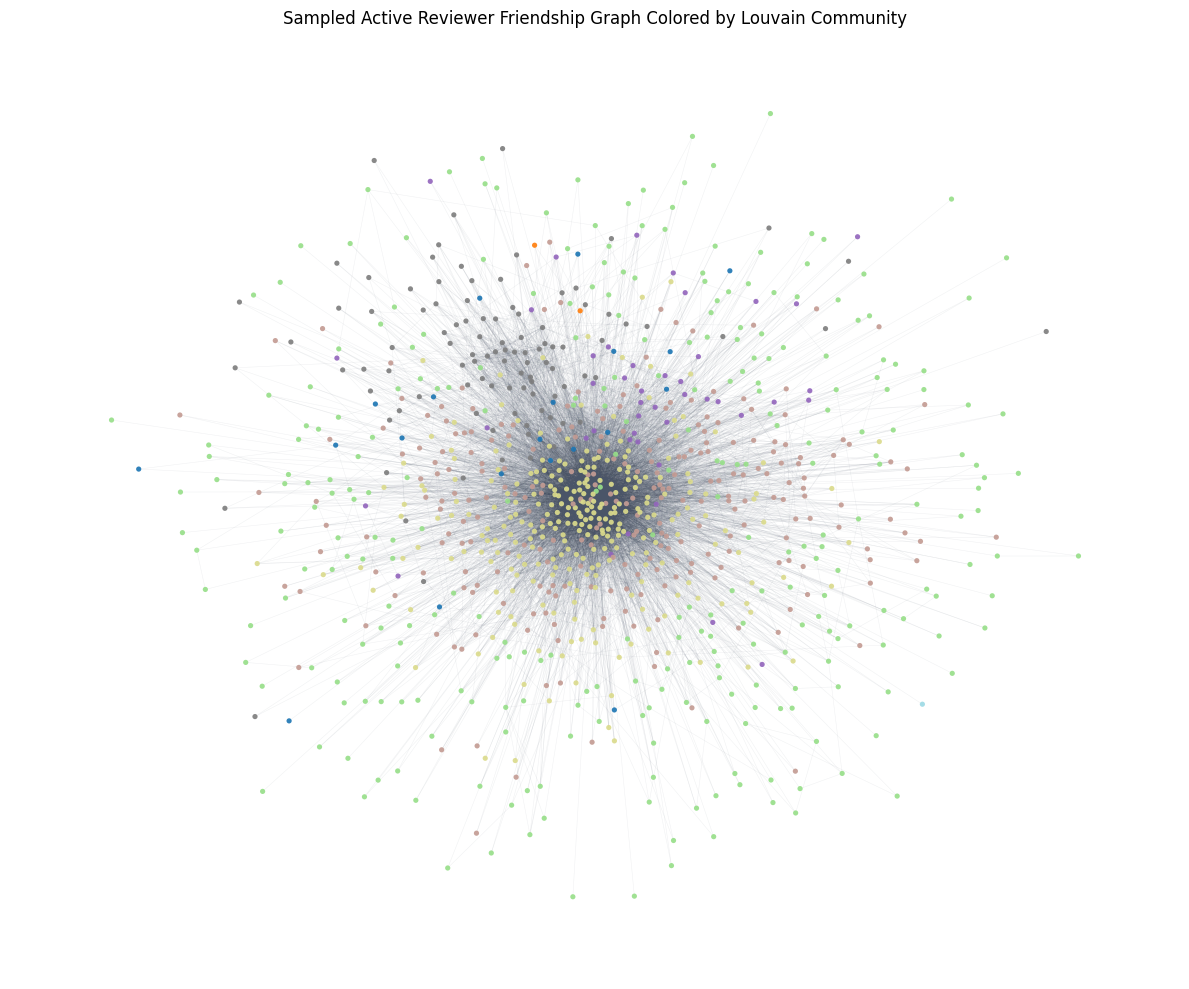

Sampled nodes: 1,000
Sampled edges: 11,579
Saved: outputs\figures\sna\community_graph.png


In [13]:
# Imports
from collections import deque

# Sample largest component
largest_component_nodes = set(components[0]) if components else set()
sample_size = min(1000, len(largest_component_nodes))

if sample_size:
    largest_component_subgraph = G.subgraph(largest_component_nodes)
    start_node = max(largest_component_nodes, key=lambda node: G.degree(node))
    sampled_nodes = []
    seen_nodes = {start_node}
    frontier = deque([start_node])

    while frontier and len(sampled_nodes) < sample_size:
        node = frontier.popleft()
        sampled_nodes.append(node)

        new_neighbors = [
            neighbor
            for neighbor in largest_component_subgraph.neighbors(node)
            if neighbor not in seen_nodes
        ]
        new_neighbors = sorted(new_neighbors, key=lambda neighbor: G.degree(neighbor), reverse=True)

        for neighbor in new_neighbors:
            seen_nodes.add(neighbor)
            frontier.append(neighbor)

    if len(sampled_nodes) < sample_size:
        remaining_nodes = [
            node
            for node in sorted(largest_component_nodes)
            if node not in set(sampled_nodes)
        ]
        sampled_nodes.extend(
            pd.Series(remaining_nodes)
            .sample(n=sample_size - len(sampled_nodes), random_state=42)
            .tolist()
        )

    sampled_subgraph = G.subgraph(sampled_nodes[:sample_size]).copy()
else:
    sampled_subgraph = G.copy()

# Community colors
sampled_communities = [louvain_partition.get(node, -1) for node in sampled_subgraph.nodes()]
community_color_lookup = {
    community_id: idx
    for idx, community_id in enumerate(sorted(set(sampled_communities)))
}
node_color_values = [community_color_lookup[community_id] for community_id in sampled_communities]

# Graph layout
layout = nx.spring_layout(
    sampled_subgraph,
    seed=42,
    weight="weight",
    iterations=60,
    k=0.16,
)

# Plot graph
fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_edges(
    sampled_subgraph,
    layout,
    ax=ax,
    alpha=0.08,
    width=0.4,
    edge_color="#4A5568",
)
nx.draw_networkx_nodes(
    sampled_subgraph,
    layout,
    ax=ax,
    node_size=14,
    node_color=node_color_values,
    cmap=plt.cm.tab20,
    linewidths=0,
    alpha=0.92,
)
ax.set_title("Sampled Active Reviewer Friendship Graph Colored by Louvain Community")
ax.set_axis_off()
fig.tight_layout()

# Save figure
community_graph_path = FIGURES_DIR / "community_graph.png"
fig.savefig(community_graph_path, dpi=180)
plt.show()
plt.close(fig)

print(f"Sampled nodes: {sampled_subgraph.number_of_nodes():,}")
print(f"Sampled edges: {sampled_subgraph.number_of_edges():,}")
print(f"Saved: {community_graph_path.relative_to(PROJECT_ROOT)}")

## Community Structure Interpretation

The training-window Louvain communities reveal that the New Orleans Yelp reviewer graph is not one uniform audience. It contains dense local reviewer clusters that likely reflect overlapping friendship circles, shared dining and nightlife routines, tourism-oriented reviewers, and users who repeatedly review the same high-visibility local businesses during 2015-2017. The largest communities matter most for forecasting because they represent recurring pools of social attention: when several users from the same cluster review a business, the signal is less like isolated demand and more like activity spreading through a recognizable reviewer neighborhood. At the same time, the many isolated or tiny communities show the limit of the friendship graph: Yelp activity is partly social, but a large share of local reviewing still happens outside observed friendship ties.


## SNA Takeaways

- The selected graph is fit only on **2015-02 through 2017-12** reviews, matching the later forecasting training split.
- The active-reviewer threshold remains **5 training-window reviews**.
- All exported `user_network_features.csv` centrality, component, and community labels are therefore learned without validation, test, or post-2019 review activity.
- These features are best interpreted as social exposure signals for later business-month aggregation, not causal influence.


## SNA Limitations

- Yelp friendship links are static in the available dataset, so the graph cannot show when relationships formed.
- Network features measure social exposure among reviewers, not causal influence over future reviews.
- Sparse friendship coverage means some active reviewers have weak or missing network signal even when they are important locally.
- The train-only SNA graph intentionally ignores reviewers and shared-business relationships that appear only after 2017, so validation/test businesses may have weaker social coverage by design.
